# Week Problem Set: Data Wrangling

## Context
You are a Data Scientist at a regional health center. Patient data is divided across three systems:
- Administrative
- Lab Results
- Lifestyle Surveys

For this assignment, you will work with these datasets **independently** and focus only on **data wrangling tasks**.

---

## Datasets
1. patient_demographics.csv  
   - Patient ID, Age, Sex, Geography
     

2. clinical_data.csv  
   - Patient ID, Cholesterol, Blood Pressure ("120/80"), BMI
  

3. lifestyle_factors.csv  
   - Patient ID, Smoking, Diet, Heart Attack Risk (Target)

---

## Objectives
- Inspecting structure and quality
- Handling missing values
- Fixing data formats
- Identifying and treating anomalies

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically
- Make decisions (and justify them)
- Explore different approaches

---

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Download the following CSV files from Google Classroom to your computer:

- patient_demographics.csv
- clinical_data.csv
- lifestyle_factors.csv

Run the code below and upload the files.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving patient_demographics.csv to patient_demographics.csv
Saving lifestyle_factors.csv to lifestyle_factors.csv
Saving clinical_data.csv to clinical_data.csv


In [ ]:
# Load datasets
demographics = pd.read_csv("/content/patient_demographics.csv")
clinical = pd.read_csv("/content/clinical_data.csv")
lifestyle = pd.read_csv("/content/lifestyle_factors.csv")

# Basic Inspection

## Tasks:
- View first few rows
- Check datatypes
- Look at summary statistics

## Questions:
- Are there obvious data issues?
- Are datatypes appropriate?

## Hint:
- Use `.head()`, `.info()`, `.describe()` for all three dataframes to get a full picture of the data quality.
- Pandas documentation for reference: https://pandas.pydata.org/docs/user_guide/10min.html

In [ ]:
# inspecting demographics dataframe

display(demographics.head())
display(demographics.info())
display(demographics.describe())


,Patient ID,Age,Sex,Income,Country,Continent,Hemisphere
0,BMW7812,67,Male,261404,Argentina,South America,Southern Hemisphere
1,CZE1114,21,Male,285768,Canada,North America,Northern Hemisphere
2,BNI9906,21,Female,235282,France,Europe,Northern Hemisphere
3,JLN3497,84,Male,125640,Canada,North America,Northern Hemisphere
4,GFO8847,66,Male,160555,Thailand,Asia,Northern Hemisphere


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Patient ID  8763 non-null   object
 1   Age         8763 non-null   int64 
 2   Sex         8763 non-null   object
 3   Income      8763 non-null   int64 
 4   Country     8763 non-null   object
 5   Continent   8763 non-null   object
 6   Hemisphere  8763 non-null   object
dtypes: int64(2), object(5)
memory usage: 479.4+ KB


None

,Age,Income
count,8763.000000,8763.000000
mean,53.707977,158263.181901
std,21.249509,80575.190806
min,18.000000,20062.000000
25%,35.000000,88310.000000
50%,54.000000,157866.000000
75%,72.000000,227749.000000
max,90.000000,299954.000000


**About demographics data**
<br>represents patients's basic identity records
<br>Patient Identifier - Patient ID
<br>contains 8763 total entries
<br>no null rows
<br>no data type issues observed

In [ ]:
# inspecting clinical data
display(clinical.head())
display(clinical.info())
display(clinical.describe())

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI
0,BMW7812,208,158/88,72,0,0,286,31.251233
1,CZE1114,389,165/93,98,1,1,235,27.194973
2,BNI9906,324,174/99,72,1,0,587,28.176571
3,JLN3497,383,163/100,73,1,1,378,36.464704
4,GFO8847,318,91/88,93,1,1,231,21.809144


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient ID      8763 non-null   object 
 1   Cholesterol     8763 non-null   int64  
 2   Blood Pressure  8763 non-null   object 
 3   Heart Rate      8763 non-null   int64  
 4   Diabetes        8763 non-null   int64  
 5   Family History  8763 non-null   int64  
 6   Triglycerides   8763 non-null   int64  
 7   BMI             8763 non-null   float64
dtypes: float64(1), int64(5), object(2)
memory usage: 547.8+ KB


None

,Cholesterol,Heart Rate,Diabetes,Family History,Triglycerides,BMI
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,259.877211,75.021682,0.652288,0.492982,417.677051,28.891446
std,80.863276,20.550948,0.476271,0.499979,223.748137,6.319181
min,120.000000,40.000000,0.000000,0.000000,30.000000,18.002337
25%,192.000000,57.000000,0.000000,0.000000,225.500000,23.422985
50%,259.000000,75.000000,1.000000,0.000000,417.000000,28.768999
75%,330.000000,93.000000,1.000000,1.000000,612.000000,34.324594
max,400.000000,110.000000,1.000000,1.000000,800.000000,39.997211


**About clinical data**
<br>contains basic clinical test records of patient
<br>Patient ID can be considered as unique identifier
<br>contains 8763 total entries
<br>no null rows
<br>no data type issues observed

In [ ]:

  # inspecting lifestyle data
display(lifestyle.head())
display(lifestyle.info())
display(lifestyle.describe())

,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
0,BMW7812,1,0,0,4.168189,Average,9,0
1,CZE1114,1,1,1,1.813242,Unhealthy,1,0
2,BNI9906,0,0,0,2.078353,Healthy,9,0
3,JLN3497,1,0,1,9.828130,Average,9,0
4,GFO8847,1,1,0,5.804299,Unhealthy,6,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient ID               8763 non-null   object 
 1   Smoking                  8763 non-null   int64  
 2   Obesity                  8763 non-null   int64  
 3   Alcohol Consumption      8763 non-null   int64  
 4   Exercise Hours Per Week  8763 non-null   float64
 5   Diet                     8763 non-null   object 
 6   Stress Level             8763 non-null   int64  
 7   Heart Attack Risk        8763 non-null   int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 547.8+ KB


None

,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Stress Level,Heart Attack Risk
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,0.896839,0.501426,0.598083,10.014284,5.469702,0.358211
std,0.304186,0.500026,0.490313,5.783745,2.859622,0.479502
min,0.000000,0.000000,0.000000,0.002442,1.000000,0.000000
25%,1.000000,0.000000,0.000000,4.981579,3.000000,0.000000
50%,1.000000,1.000000,1.000000,10.069559,5.000000,0.000000
75%,1.000000,1.000000,1.000000,15.050018,8.000000,1.000000
max,1.000000,1.000000,1.000000,19.998709,10.000000,1.000000


**About Patients Lifestyle data**
<br>Contains data that shows the patient living style from consumption to physical and mental conditioning
<br>Unique identifier - Patient ID
<br>8763 total entries
<br>no null entries
<br>appropriate data type

# Data Cleaning

## 1. Blood Pressure Column

### Task:
- Inspect the Blood Pressure column

### Questions:
- Is it stored as a number or string?
- Can we compute averages directly?

### Hint:
- Format looks like "120/80"
- Consider splitting into two columns
- https://pandas.pydata.org/docs/reference/api/pandas.Series.str.split.html

### Consequences:
- Keeping as string -> limits analysis
- Splitting -> enables calculations but increases feature count

In [ ]:
# Inspecting blood pressure column

display(clinical['Blood Pressure'].dtypes)
display(clinical['Blood Pressure'].head())


dtype('O')

,Blood Pressure
0,158/88
1,165/93
2,174/99
3,163/100
4,91/88


Blood Pressure feature has Object Data type
<br>consists of records in the format "systolic/diastolic"
<br>need to split the column into two newer columns : "systolic" and "diastolic"

In [ ]:
# splitting blood pressure into systolic and diastolic
clinical[['systolic','diastolic']] = clinical['Blood Pressure'].str.split('/', expand=True)
display(clinical.head())



,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI,systolic,diastolic
0,BMW7812,208,158/88,72,0,0,286,31.251233,158,88
1,CZE1114,389,165/93,98,1,1,235,27.194973,165,93
2,BNI9906,324,174/99,72,1,0,587,28.176571,174,99
3,JLN3497,383,163/100,73,1,1,378,36.464704,163,100
4,GFO8847,318,91/88,93,1,1,231,21.809144,91,88


In [ ]:
clinical[['systolic','diastolic']].describe()

,systolic,diastolic
count,8763,8763
unique,91,51
top,102,83
freq,123,198


Object type can not have averages calculated. Thus, it should be converted to float or int type.

In [ ]:
clinical[['systolic','diastolic']]=clinical[['systolic','diastolic']].astype(float)
clinical[['systolic','diastolic']].describe()

,systolic,diastolic
count,8763.000000,8763.000000
mean,135.075659,85.156111
std,26.349976,14.676565
min,90.000000,60.000000
25%,112.000000,72.000000
50%,135.000000,85.000000
75%,158.000000,98.000000
max,180.000000,110.000000


converted to "float" type for aggregation of the "systolic" and "diastolic" columns.


## 2. Missing Values

### Task:
Identify columns with null values

### Questions:
- Which columns have missing values?
- Why might values be missing?

### Hint:
- Lifestyle → user did not answer (non-critical)
- Clinical → test not performed (critical)
- https://wesmckinney.com/book/data-cleaning

### Why Missing Data Matters
Missing data is not just an inconvenience, it can affect the **validity of your analysis**.

There are different types of missingness:
- **MCAR (Missing Completely at Random)** → no pattern (least problematic)
- **MAR (Missing at Random)** → depends on other variables
- **MNAR (Missing Not at Random)** → depends on the missing value itself (most problematic)

Understanding *why* data is missing helps decide how to handle it.

### Consequences of Different Choices

#### 1. Dropping Missing Values (`dropna`)
- Pros: simple, clean dataset  
- Cons: loses data, may introduce bias  

---

#### 2. Filling Missing Values (`fillna`)
- Pros: keeps dataset size, usable for modeling  
- Cons: adds assumptions, can distort data  

---

#### 3. Column-Specific Strategy
- Clinical → careful imputation or flag missing  
- Lifestyle → consider "Unknown" category  

### Key Takeaway:
There is **no single correct method**.  
The best approach depends on:
- Why data is missing  
- How much is missing  
- The impact on downstream analysis  


In [ ]:
# Null value inspection
display(demographics.isnull().sum())
display(clinical.isnull().sum())
display(lifestyle.isnull().sum())

,0
Patient ID,0
Age,0
Sex,0
Income,0
Country,0
Continent,0
Hemisphere,0


,0
Patient ID,0
Cholesterol,0
Blood Pressure,0
Heart Rate,0
Diabetes,0
Family History,0
Triglycerides,0
BMI,0
systolic,0
diastolic,0


,0
Patient ID,0
Smoking,0
Obesity,0
Alcohol Consumption,0
Exercise Hours Per Week,0
Diet,0
Stress Level,0
Heart Attack Risk,0


Since no null entries were found, no need for filling null values

In [ ]:
print('--- Demographics Inconsistencies ---')
for col in ['Sex', 'Country', 'Continent', 'Hemisphere']:
    print(f'\nUnique values for {col}:')
    print(demographics[col].value_counts())

print('\n--- Clinical Inconsistencies ---')
# For clinical, let's check diabetes and family history if they are truly binary (0 or 1)
for col in ['Diabetes', 'Family History']:
    print(f'\nUnique values for {col}:')
    print(clinical[col].value_counts())

print('\n--- Lifestyle Inconsistencies ---')
for col in ['Smoking', 'Obesity', 'Alcohol Consumption', 'Diet']:
    print(f'\nUnique values for {col}:')
    print(lifestyle[col].value_counts())

--- Demographics Inconsistencies ---

Unique values for Sex:
Sex
Male      6111
Female    2652
Name: count, dtype: int64

Unique values for Country:
Country
Germany           477
Argentina         471
Brazil            462
United Kingdom    457
Australia         449
Nigeria           448
France            446
Canada            440
China             436
New Zealand       435
Japan             433
Italy             431
Spain             430
Colombia          429
Thailand          428
South Africa      425
Vietnam           425
United States     420
India             412
South Korea       409
Name: count, dtype: int64

Unique values for Continent:
Continent
Asia             2543
Europe           2241
South America    1362
Australia         884
Africa            873
North America     860
Name: count, dtype: int64

Unique values for Hemisphere:
Hemisphere
Northern Hemisphere    5660
Southern Hemisphere    3103
Name: count, dtype: int64

--- Clinical Inconsistencies ---

Unique values for Di

# Exploratory Data Analysis (EDA)

## Univariate Analysis: Age Distribution

Univariate analysis examines **one variable at a time**.
The goal is to understand each column's distribution, central tendency, and spread before comparing variables.

We split variables into two types:
- **Numerical** (continuous): Age, Cholesterol, BMI, Blood Pressure
- **Categorical** (discrete): Sex, Smoking, Diet, Country

---

## 1. Numerical Variables : Distributions

### Task:
Plot histograms and KDE (Kernel Density Estimate) curves for: Age, Cholesterol, BMI

### Questions:
- Which variables are normally distributed?
- Which variables are skewed left or right?
- Are there any unexpected spikes or gaps?
- Based on the distribution shape, would any feature likely need a transformation before modeling?

### Hint:
- `sns.histplot(data=df, x='Age', kde=True)` draws a histogram with a density curve
- `plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Mean')` adds a mean line
- Skewness > 1 or < -1 is considered highly skewed

## Why This Matters

Many statistical models, such as **Linear Regression, Logistic Regression, and Linear Discriminant Analysis** assume that numerical features are approximately **normally distributed**. When this assumption is violated, it can lead to:

- Biased coefficients  
- Unreliable p-values  
- Poor model performance  

Even though tree-based models (like Decision Trees) do not require normality, highly skewed features can still negatively affect **distance-based algorithms** such as **KNN** or **SVM**.

This is why understanding the shape of your distributions early in **Exploratory Data Analysis (EDA)** is important. It helps determine whether transformations are needed before modeling.

---

## Common Transformations and When to Use Them

### 1. Log Transform — `np.log1p(x)`
Used when data is **right-skewed** (long tail on the right), such as income or cholesterol levels in some populations.

- Compresses large values  
- Pulls distribution closer to normal  
- Uses `log1p` (log(1 + x)) to safely handle zero values  

---

### 2. Square Root Transform — `np.sqrt(x)`
A milder transformation compared to log.

- Useful for **moderately right-skewed data**  
- Common for count data (e.g., number of medications)  
- Preserves more of the original structure  

---

### 3. Box-Cox Transform — `scipy.stats.boxcox(x)`
A powerful, data-driven transformation.

- Finds optimal power (λ) to best approximate normality  
- Requires all values to be **strictly positive**  
- Special cases:
  - λ = 0 → log transform  
  - λ = 0.5 → square root transform  

---

### 4. Yeo-Johnson Transform — `sklearn.preprocessing.PowerTransformer(method='yeo-johnson')`
A flexible alternative to Box-Cox.

- Works with **zero and negative values**  
- More suitable for real-world medical datasets  
- Automatically learns best transformation  

---

### 5. Standardization (Z-score) — `sklearn.preprocessing.StandardScaler`
Transforms features to have:

- Mean = 0  
- Standard deviation = 1  

Notes:

- Does **not change distribution shape**  
- Useful when features are on different scales (e.g., Age vs Cholesterol)  
- Does not fix skewness  

---

### 6. Min-Max Normalization — `sklearn.preprocessing.MinMaxScaler`
Rescales features to a fixed range:

- Values are scaled to **[0, 1]**  
- Does not fix skewness  

---

### Reference links:
- https://towardsdatascience.com/top-3-methods-for-handling-skewed-data-1334e0debf45/
- https://www.geeksforgeeks.org/python/data-normalization-with-pandas/


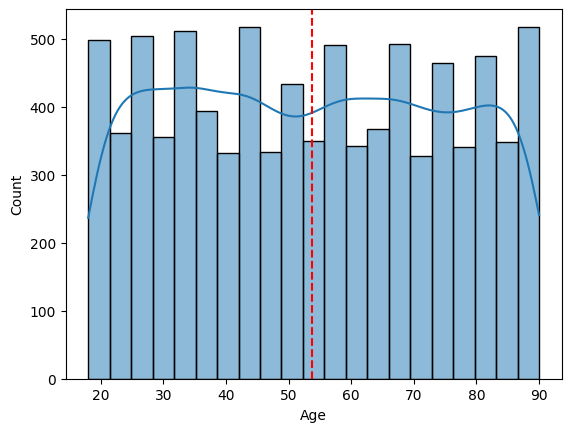

0.028497567159389177


In [ ]:
# histogram with kde for Age
sns.histplot(data=demographics, x='Age', kde=True)
plt.axvline(demographics['Age'].mean(), color='red', linestyle='--', label='Mean')
plt.show()

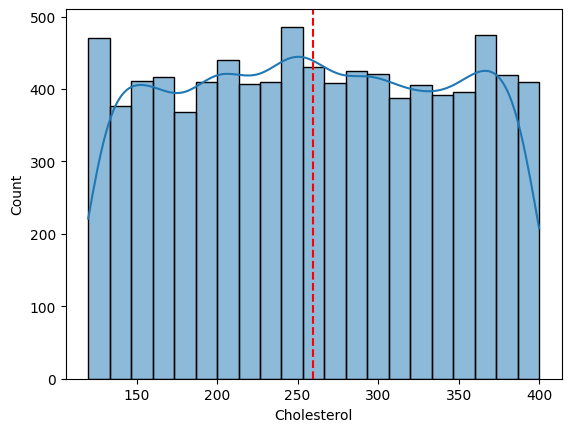

In [ ]:
# histogram with kde for Cholesterol

sns.histplot(data=clinical, x='Cholesterol', kde=True)
plt.axvline(clinical['Cholesterol'].mean(), color='red', linestyle='--', label='Mean')
plt.show()

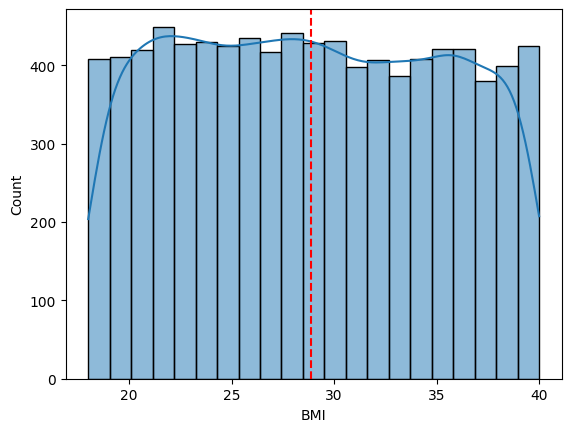

In [ ]:
# histogram with kde for BMI

sns.histplot(data=clinical, x='BMI', kde=True)
plt.axvline(clinical['BMI'].mean(), color='red', linestyle='--', label='Mean')
plt.show()

All features i.e. Age, Cholesterol and BMI are symmetrical in distribution.<br>
Hence no need to perform any transformation


## 2. Categorical Variables : Bar Charts

### Task:
Plot bar charts showing the frequency distribution of: Smoking Status, Diet Quality, and Top 10 Countries

### Questions:
- What proportion of patients smoke?
- Which diet category is most common?
- Which countries are most represented?

### Hint:
- `sns.countplot(data=df, x='Smoking', order=df['Smoking'].value_counts().index)` orders bars by frequency
- For Country, filter to top 10: `df['Country'].value_counts().head(10)`
- Rotate x-axis labels if needed: `plt.xticks(rotation=45)`

### Why This Matters:
Imbalanced categories (e.g., 90% male patients) can introduce bias into analyses. Knowing category proportions helps interpret group-level results accurately.

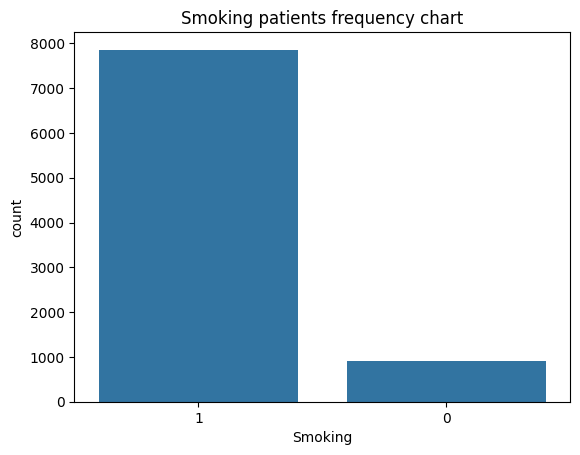

In [ ]:
# Bar chart for Smoking Status
plt.title("Smoking patients frequency chart")
sns.countplot(data=lifestyle, x = "Smoking", order=lifestyle["Smoking"].value_counts().index)
plt.show()

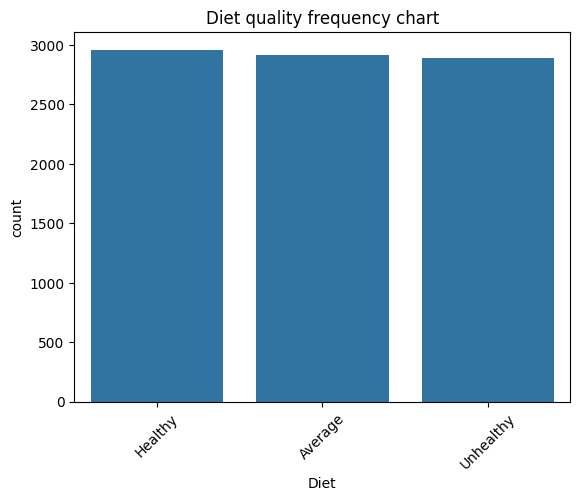

In [ ]:
# Bar chart for Diet Quality
plt.title("Diet quality frequency chart")
sns.countplot(data=lifestyle, x = "Diet", order= lifestyle["Diet"].value_counts().index)
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_11273/2423040592.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=demographics, x=demographics["Country"], order = top_10_countries, palette='viridis')


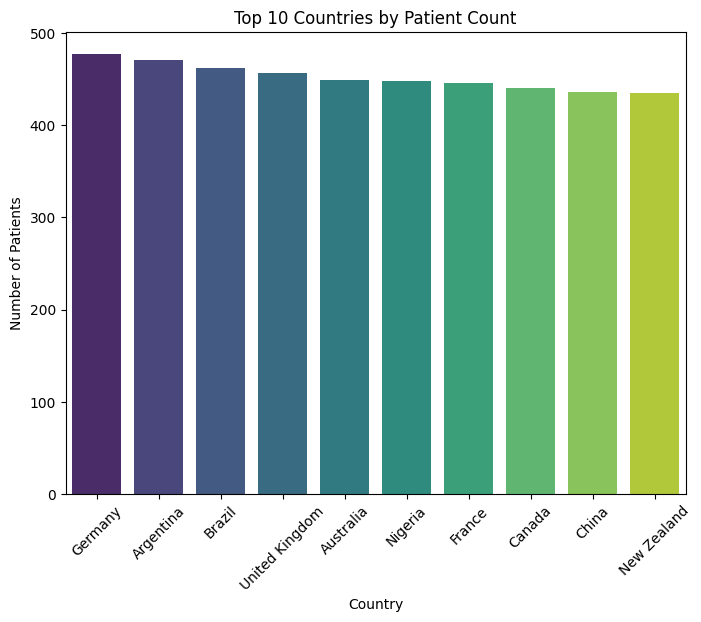

In [ ]:
# Bar chart for Top 10 Countries
plt.subplots(figsize=(8,6))
top_10_countries = demographics['Country'].value_counts().head(10).index
sns.countplot(data=demographics, x=demographics["Country"], order = top_10_countries, palette='viridis')
plt.title('Top 10 Countries by Patient Count')
plt.xlabel('Country')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()

In [ ]:
display(demographics['Country'].value_counts().sort_values(ascending=False).head(10))

,count
Country,
Germany,477
Argentina,471
Brazil,462
United Kingdom,457
Australia,449
Nigeria,448
France,446
Canada,440
China,436


# Bivariate Analysis : Features vs Target

## Context
Bivariate analysis explores the relationship **between two variables**.
Here, we are specifically interested in how each feature relates to `Heart Attack Risk` (our target).

This is where we start forming hypotheses:
- Do smokers have higher risk?
- Does diet quality affect risk?
- Does cholesterol level differ between risk groups?

---

## Categorical Features vs Heart Attack Risk (Grouped Bar Charts)

### Task:
For the categorical features: Smoking, Diet, Sex, create a grouped bar chart showing the count of At-Risk vs Not-At-Risk patients within each category.

### Questions:
- Do smokers show noticeably higher risk counts?
- Does diet quality appear protective against heart attack risk?
- Is there a difference in risk between male and female patients?

### Hint:
- `sns.countplot(data=df, x='Smoking', hue='Heart Attack Risk')` creates grouped bars automatically
- `hue` splits each bar group by the target variable
- To see proportions (not raw counts) within groups, compute:
  `df.groupby('Smoking')['Heart Attack Risk'].mean()` → gives risk rate per group

### Why This Matters:
Raw counts can be misleading if groups have unequal sizes. Consider also plotting proportions (risk rate) to compare groups fairly.

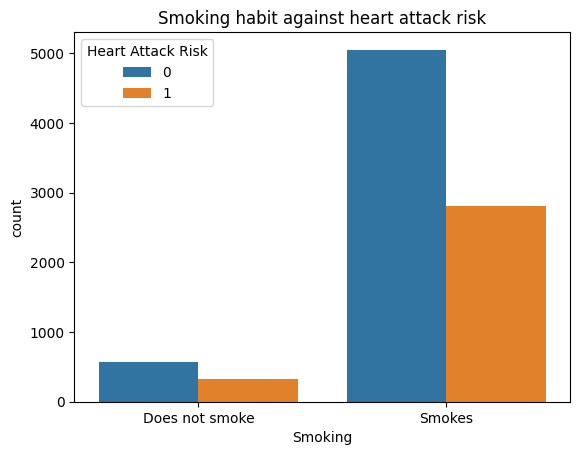

Smoking
0    0.363938
1    0.357552
Name: Heart Attack Risk, dtype: float64


In [ ]:
# Smoking to Heart Attack Risk comparision
plt.title("Smoking habit against heart attack risk")
sns.countplot(data= lifestyle, x= "Smoking", hue = "Heart Attack Risk")
plt.xticks([0,1],["Does not smoke", "Smokes"])
plt.show()

print(lifestyle.groupby('Smoking')['Heart Attack Risk'].mean())

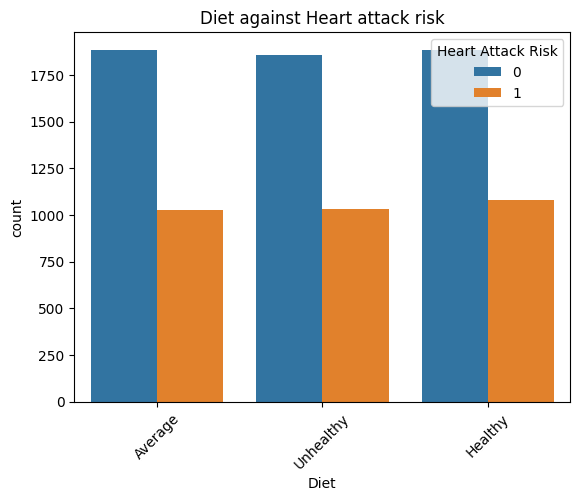

Diet
Average      0.352335
Healthy      0.364527
Unhealthy    0.357662
Name: Heart Attack Risk, dtype: float64


In [ ]:
# Does diet quality appear protective against heart attack risk?
plt.title("Diet against Heart attack risk")
sns.countplot(data= lifestyle, x= "Diet", hue = "Heart Attack Risk")
plt.xticks(rotation=45)
plt.show()

print(lifestyle.groupby("Diet")["Heart Attack Risk"].mean())

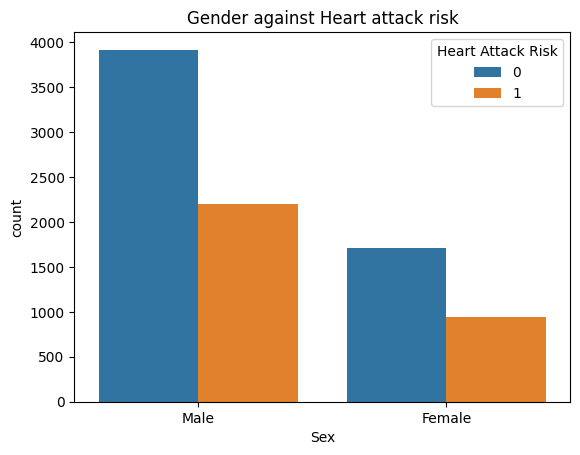

Sex
Female    0.355958
Male      0.359188
Name: Heart Attack Risk, dtype: float64


In [ ]:
merged_df = pd.merge(demographics, lifestyle, on='Patient ID', how='inner')

# Is there a difference in risk between male and female patients?
plt.title("Gender against Heart attack risk")
sns.countplot(data= merged_df, x= "Sex", hue = "Heart Attack Risk")
plt.show()

print(merged_df.groupby("Sex")["Heart Attack Risk"].mean())

# Correlation Analysis

## Context
Correlation measures **how strongly two numerical variables move together**.

### Some types of Correlation Coefficient:
| Coefficient | Use Case | Range |
|---|---|---|
| **Pearson** | Linear relationship between continuous variables | -1 to +1 |
| **Spearman** | Monotonic (ranked) relationship; robust to outliers | -1 to +1 |

### Interpretation Guide:
- |r| > 0.7 → Strong correlation  
- |r| 0.4–0.7 → Moderate correlation  
- |r| < 0.4 → Weak correlation  
- Sign (+ or -) tells direction: positive = both increase together, negative = one increases as other decreases

---

## Pearson Correlation Heatmap

### Task:
Calculate and visualize the Pearson correlation matrix for all numerical columns including the target.

### Questions:
- Which feature has the highest correlation with Heart Attack Risk?
- Are any features highly correlated with each other (multicollinearity)?
- Does Systolic BP correlate strongly with Diastolic BP? Why might that be expected?

### Hint:
- `df[numeric_cols].corr(method='pearson')` computes the correlation matrix
- `sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')` visualizes it
- `mask = np.triu(np.ones_like(corr_matrix))` removes the duplicate upper triangle

### Warning:
Pearson assumes linearity and is sensitive to outliers. For skewed distributions, consider Spearman instead.

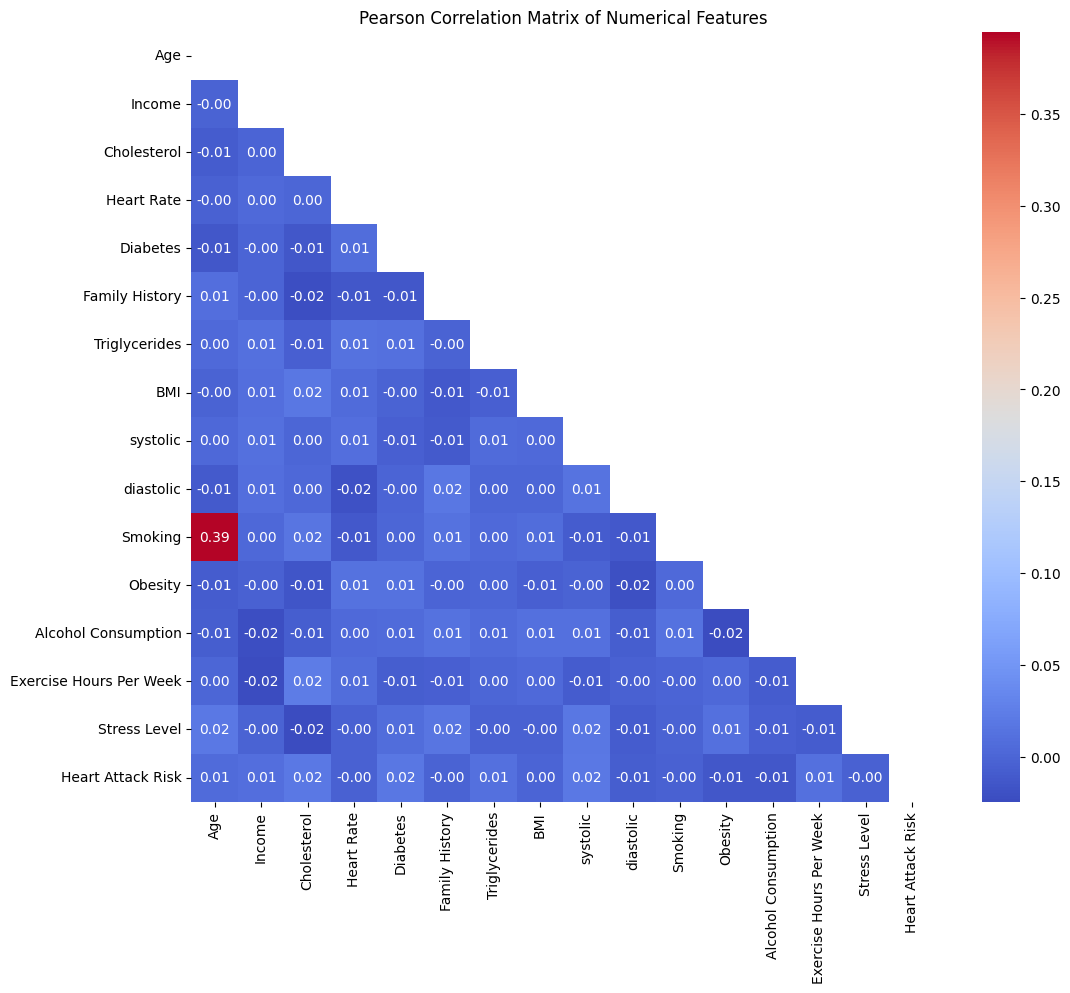

In [ ]:
#Calculation and visualization of correlation matrix using heatmap
df_merged_first = pd.merge(demographics, clinical, on='Patient ID', how='inner')
df_merged_final = pd.merge(df_merged_first, lifestyle, on='Patient ID', how='inner')

# Select only numeric columns for correlation calculation
numeric_cols = df_merged_final.select_dtypes(include=np.number).columns

pearson_correlation_matrix = df_merged_final[numeric_cols].corr(method = "pearson")
mask= np.triu(np.ones_like(pearson_correlation_matrix))

plt.figure(figsize=(12, 10))
sns.heatmap(pearson_correlation_matrix, annot=True, cmap="coolwarm", fmt='.2f', mask=mask)
plt.title('Pearson Correlation Matrix of Numerical Features')
plt.show()

# Which feature has the highest correlation with Heart Attack Risk?
- every features have very weak correlation (**0.0 to 0.02**)observed against heart attack risk
# Are any features highly correlated with each other (multicollinearity)?
- No multi collinearity observed.
- But Age has relatively higher correlationship (**0.39**) with Smoking habits than others.
# Does Systolic BP correlate strongly with Diastolic BP? Why might that be expected?
- As observed, very weak correlationship between systolic BP and diastolic BP (**0.01**)

# Spearman Correlation

### Task:
Repeat the correlation analysis using Spearman's rank correlation.

### Questions:
- Are the Spearman results significantly different from Pearson?
- If they differ, what might that suggest about the data's linearity or outliers?

### Hint:
- Use `method='spearman'` in `.corr()`
- Compare the two heatmaps side by side using `plt.subplots(1, 2)`

### Interpretation:
Large differences between Pearson and Spearman suggest the relationship is non-linear or that outliers are influencing Pearson.

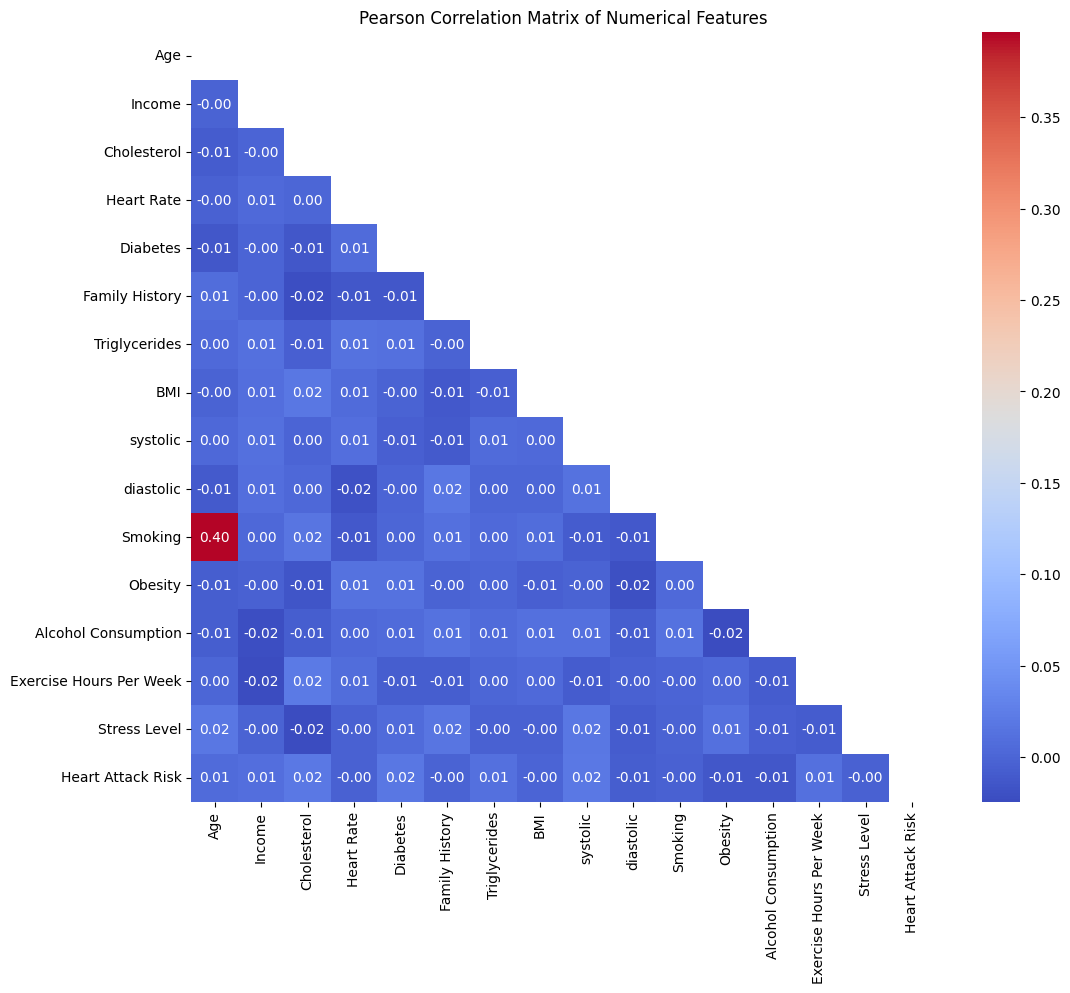

In [ ]:
# Spearman correlation heatmap
spearman_correlation_matrix = df_merged_final[numeric_cols].corr(method = "spearman")
mask= np.triu(np.ones_like(spearman_correlation_matrix))

plt.figure(figsize=(12, 10))
sns.heatmap(spearman_correlation_matrix, annot=True, cmap="coolwarm", fmt='.2f', mask=mask)
plt.title('Pearson Correlation Matrix of Numerical Features')
plt.show()

### Are the Spearman results significantly different from Pearson?
- Both correlation matrix look almost identical.
- Only visible difference is that Smoking - Age correlation = ** 0.40 **
### If they differ, what might that suggest about the data's linearity or outliers?
- no significant differences

## Target Variable Analysis: Heart Attack Risk

## Context
Target variable is the variable that the user would want to predict using the rest of the dataset.

`Heart Attack Risk` is a **binary variable**: 0 (No Risk) and 1 (At Risk).

## Tasks:
- Count how many patients fall into each class
- Visualize the class distribution with a bar chart

## Hint:
- Use `.value_counts()` to get counts
- Use `sns.countplot()` or `plt.bar()` for visualization


In [ ]:
# Count how many patients fall into each class
heart_attack_exposure_count = lifestyle["Heart Attack Risk"].value_counts()
heart_attack_exposure_count

,count
Heart Attack Risk,
0,5624
1,3139


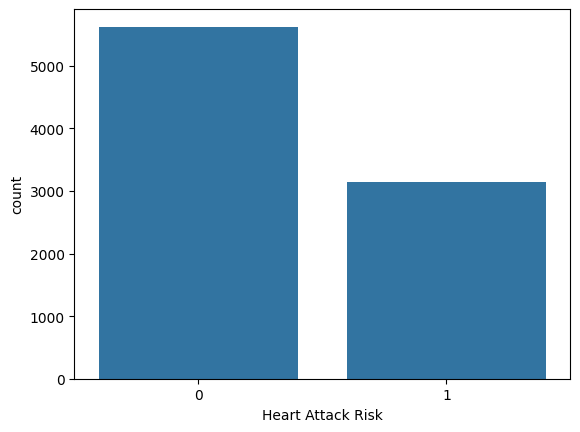

In [ ]:
# bar chart to visualize class distribution
sns.countplot(data = lifestyle, x = "Heart Attack Risk", order=heart_attack_exposure_count.index)
plt.show()

# Final Reflection

## Answer the following:

### 1. Missing Values
- How did you handle missing values in each dataset?

- Why did you choose that approach (drop, fill, or mixed strategy)?
---

### 2. Data Quality Issues
- Did you find any unrealistic or inconsistent values?
- How did you identify them?
- What action did you take (remove, clip, correct, or keep)?

---

### 3. Insights from EDA
- What patterns did you observe in the data?
- Did you find any relationships between variables (e.g., age, cholesterol, risk)?
- Were there any surprising findings or trends?
---

### 4. Correlation Findings
- Were Pearson and Spearman results similar or different? What does that suggest?

- Did you find any multicollinearity (two features highly correlated with each other)?
---

### 5. Improvements
- If you had more time, what would you improve in your data cleaning process?
- Would you try different strategies for missing values or outliers?
- What additional checks or visualizations would you add?
---


# ANSWERS:

### 1. Missing Values
- How did you handle missing values in each dataset?
> No missing values were found. Hence, no need to handle them.

- Why did you choose that approach (drop, fill, or mixed strategy)?
> Again, no approach was applied to handle missing values as null values were absent in dataset
---

### 2. Data Quality Issues
- Did you find any unrealistic or inconsistent values?
> 1) No duplicate rows found
> 2) No inconsistencies found in the given datasets
- How did you identify them?
> To look up for inconsistencies, use of pd.Series.value_counts() helps in listing out unique values in the series
- What action did you take (remove, clip, correct, or keep)?
> kept as it is since no inconsistency found

---

### 3. Insights from EDA
- What patterns did you observe in the data?
- Did you find any relationships between variables (e.g., age, cholesterol, risk)?
- Were there any surprising findings or trends?
> 1) Majority of the patients smoke.<br>
> 2) similar count observed in diet quality among patients<br>
> 3) High patient count observed in western hemisphere while looking at the visualization of top 10 countries by patient count.<br>
> 4) No such interesting relationships found in the data
---

### 4. Correlation Findings
- Were Pearson and Spearman results similar or different? What does that suggest?
> 1) Both results turned out to be almost identical
> 2) Relatively higher correlation found in between "Age" and "Smoking"

- Did you find any multicollinearity (two features highly correlated with each other)?
> No multicollinearity observed
---

### 5. Improvements
- If you had more time, what would you improve in your data cleaning process?
- Would you try different strategies for missing values or outliers?
> Additionally I would look for any outliers in numerical columns or actual data incorrectness due to failure in data collection
- What additional checks or visualizations would you add?
> An addition of Box plot for outlier detection would be good enough.
---

### Tip
There is no single correct answer here. Focus on:
- Justifying your decisions  
- Explaining trade-offs  
- Demonstrating understanding of data quality impact  